## Robustness Testing of Topographical Correlation in Tumor Simulations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import sys
import os

# Custom modules
from simulate_tumors import TumorCellSimulator, plot_cell_distribution
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from ecd_helperFunctions import *
from helperFunctions import *

#### Outline
1. Prepare data for TCM calculation
2. Generate perturbed datasets
3. Calculate TCM for each dataset
4. Calculate robustness metrics
5. Plot results

    `robustness_data = {'Sample': ['S1', 'S2', ...],
                'Baseline': [baseline_tcm1, baseline_tcm2, ...],
                'High Immune': ['high_immune_tcm1', 'high_immune_tcm2', ...],
                'High Tumor Density': ['high_ecd_tcm1', 'high_ecd_tcm2', ...]}`



In [4]:
# Load data
df = pd.read_csv('/home/ecdyer/PROJECTS/mIF_stats/simulations/S1/S1_dense_cluster.csv')

# List markers of interest
markers = ['tumor_cell', 'immune_cell']

# Keep only relevant columns
keep_cols = ['x', 'y']

# One hot encode cell types
df = create_cell_type_columns(df)

labels = {1: 'Tumor', 2: 'Immune'}

pc_df = generate_binary_pointcloud(df,
                                   markers=markers,
                                   keep_cols=keep_cols,
                                   labels=labels) 

# Check the pointcloud
pc_df.head()

,x,y,Celltype_asNumeric,Celltype
0,36672.839142,2493.013388,2,Immune
1,35959.900263,2659.239577,2,Immune
2,36600.242290,3750.319802,2,Immune
3,36676.332686,2242.100884,2,Immune
4,36425.711780,3332.286647,2,Immune


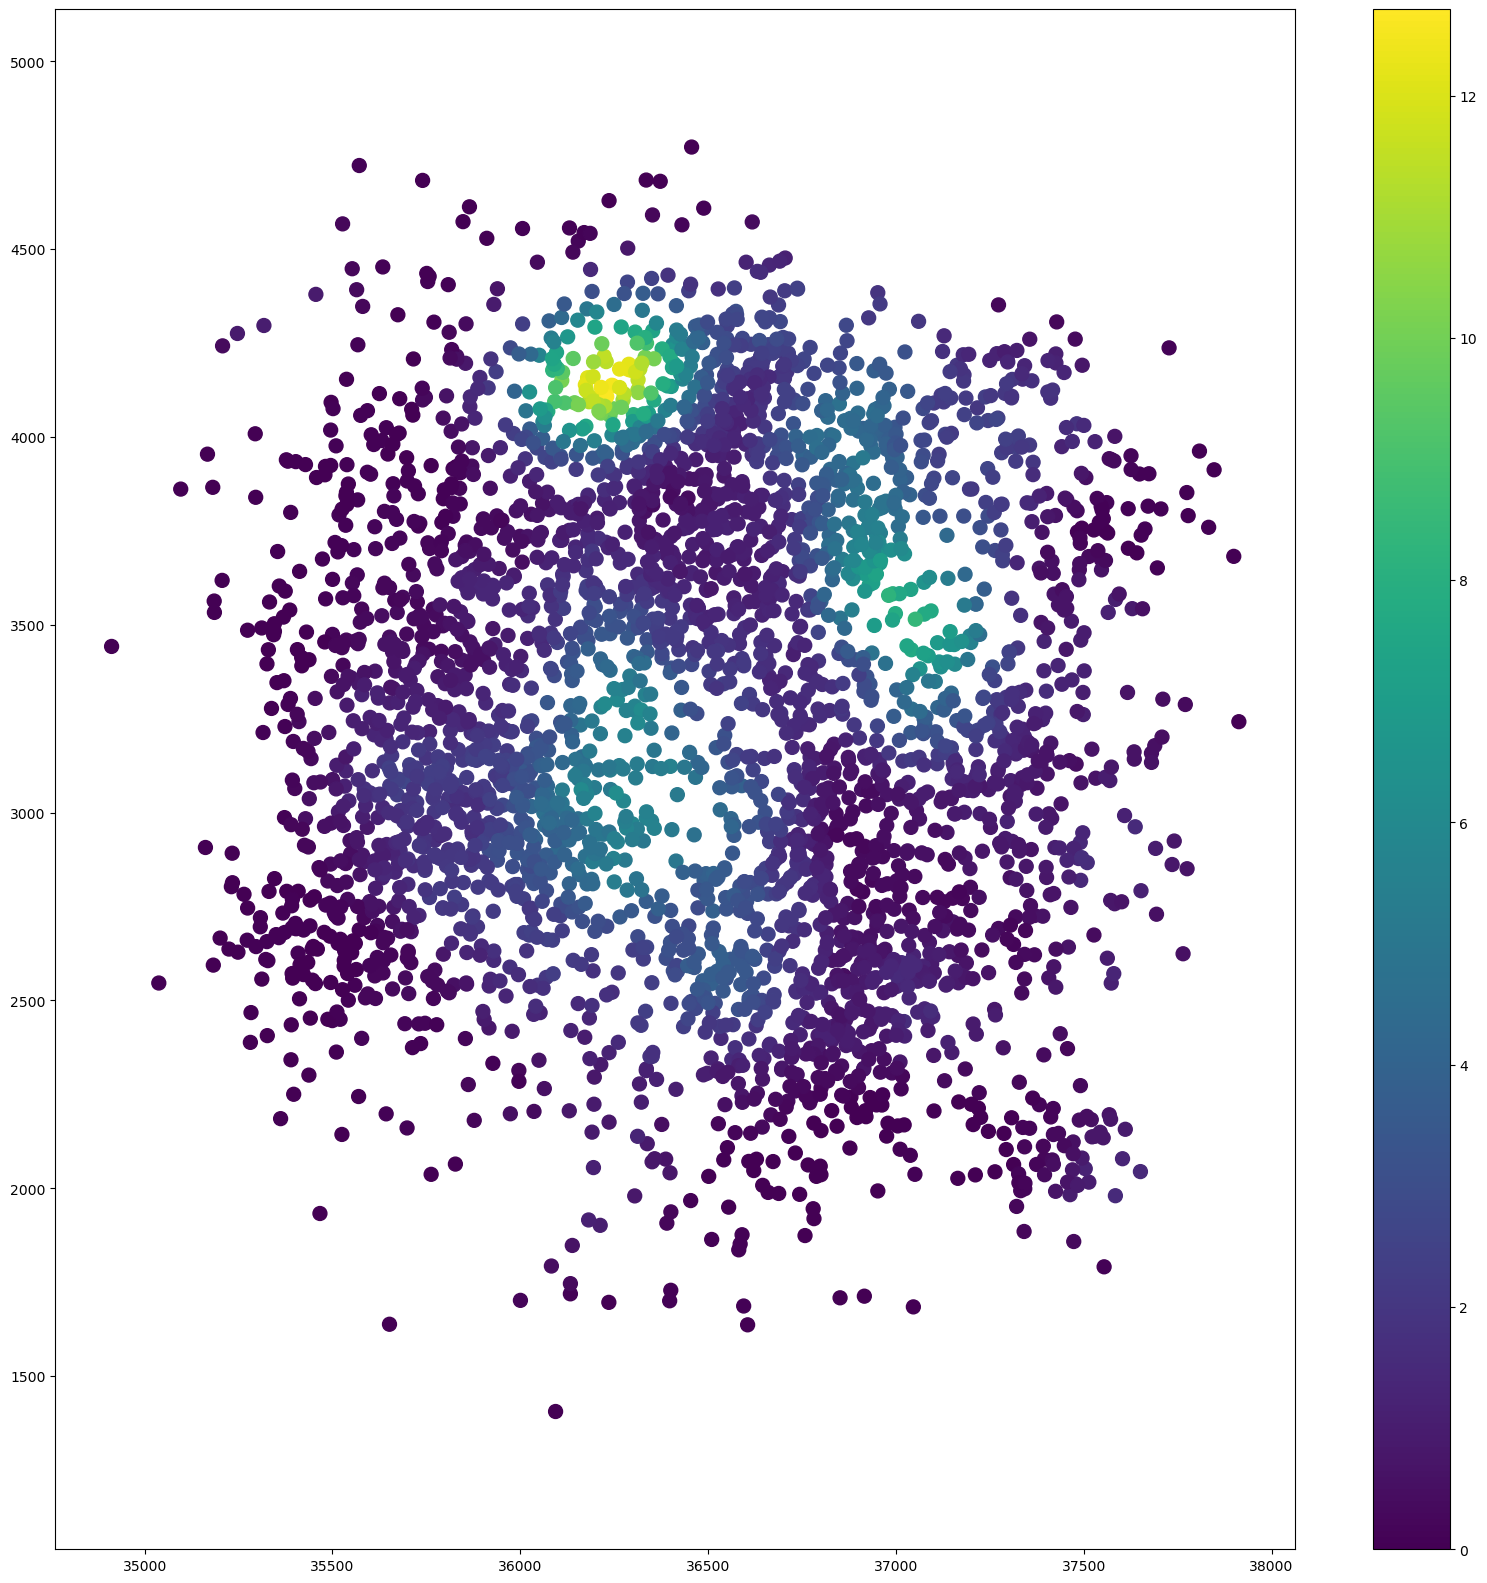

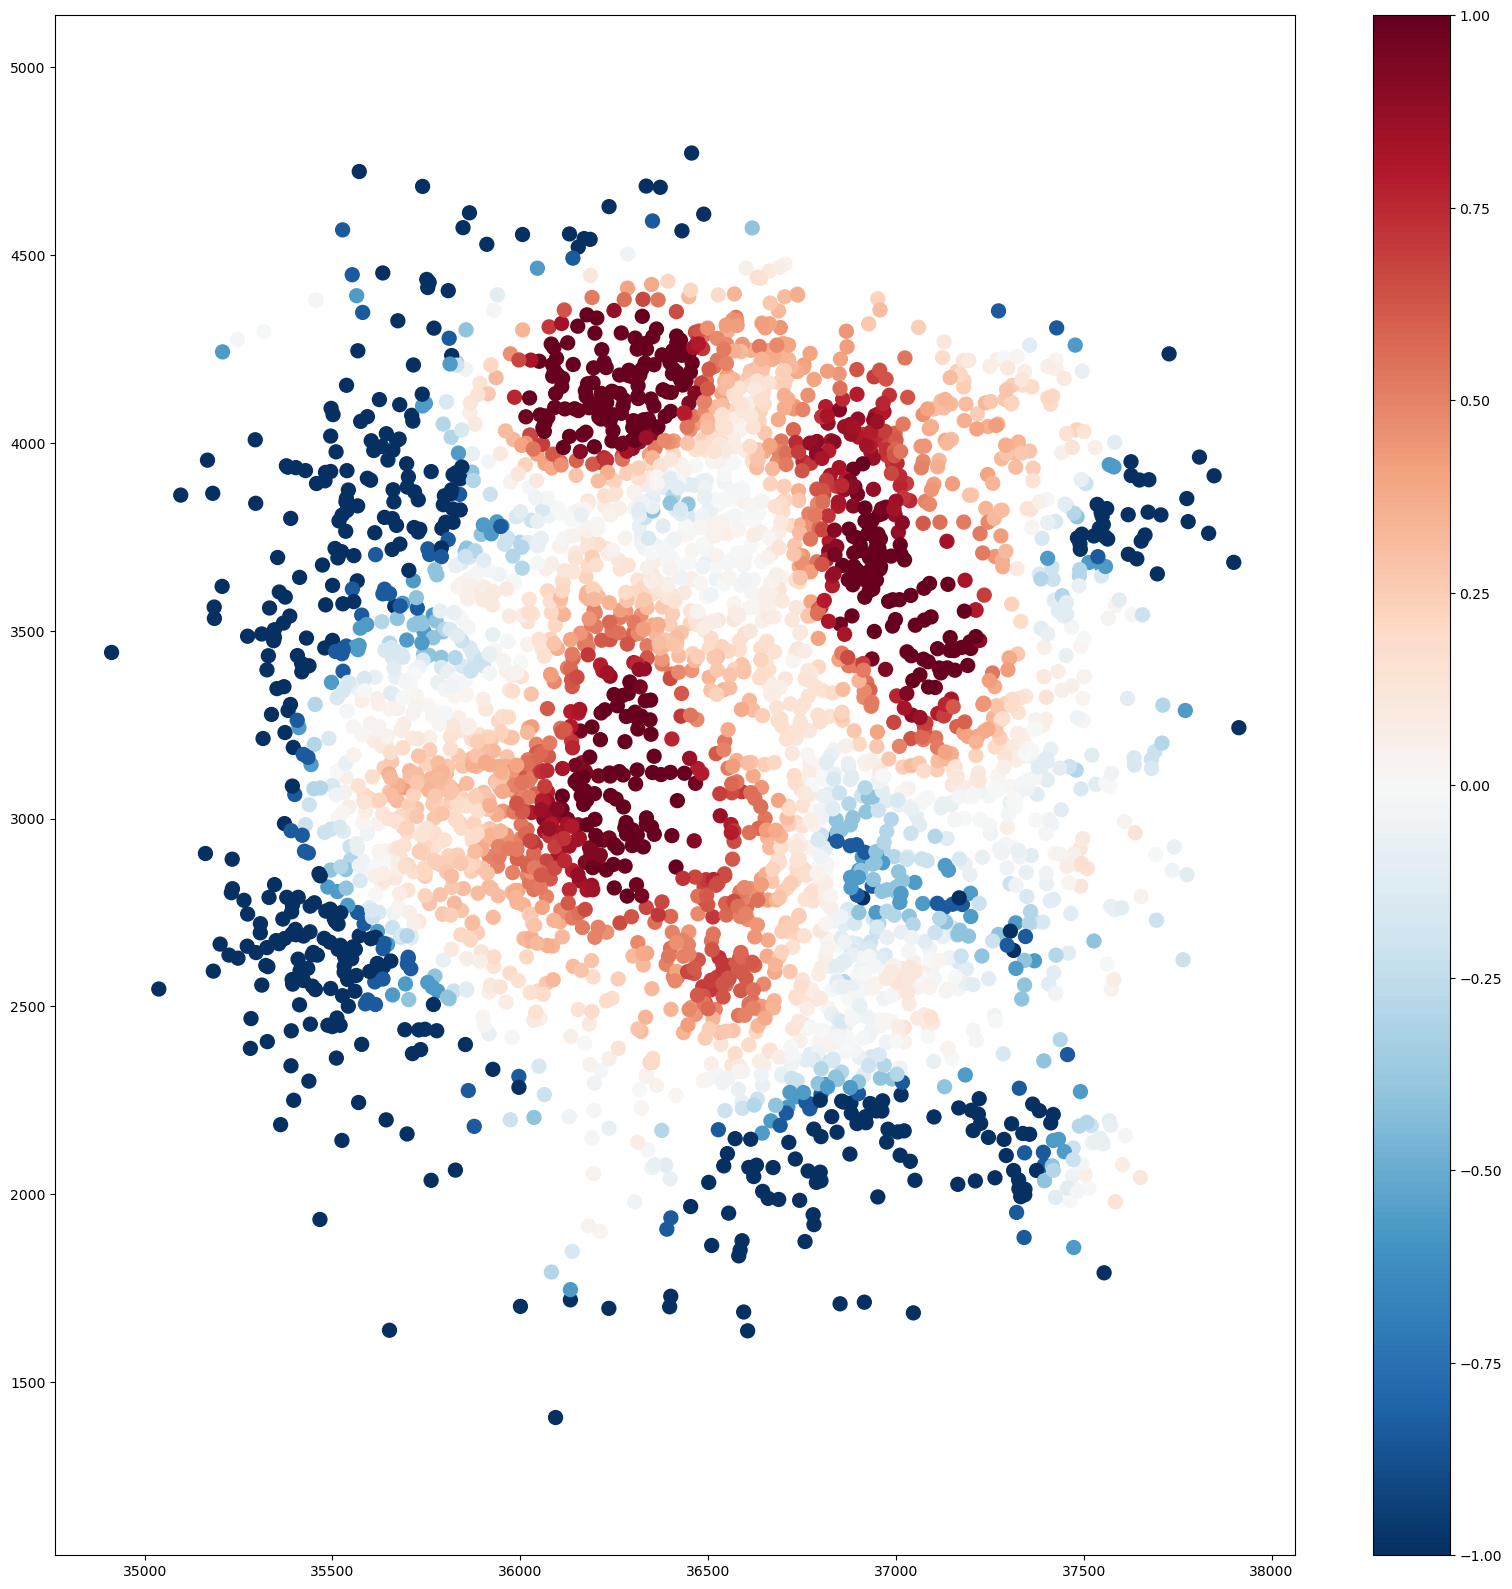

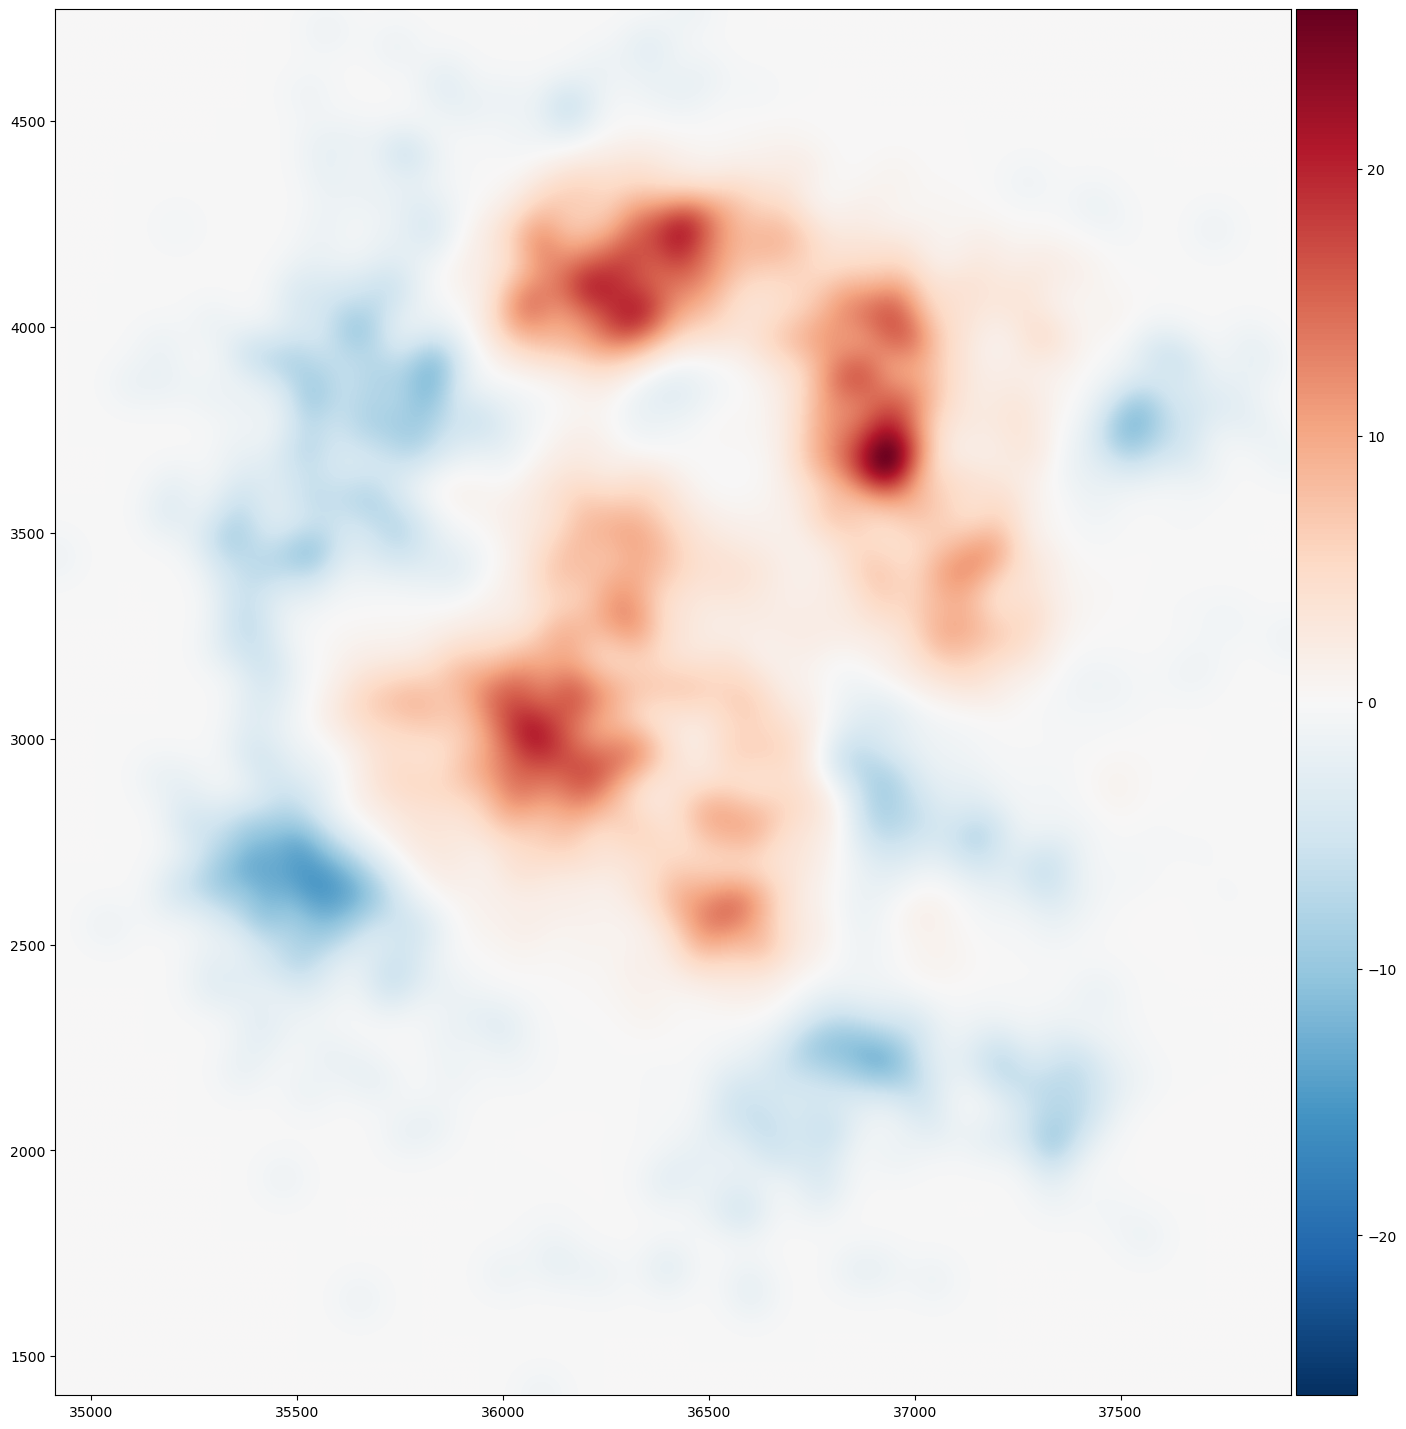

In [7]:
# Convert points to numpy array
points = np.asarray([pc_df['x'], pc_df['y']]).transpose()

# Convert pc_df['Celltype'] to a list
celltype_list = pc_df['Celltype'].tolist()

pc = generatePointCloud('tumor_immune', points)
pc.addLabels('Celltype', 'categorical', celltype_list, cmap='tab10')

# visualisePointCloud(pc, 'Celltype', markerSize=100)

# Define cell types of interest
typea = 'Tumor'
typeb = 'Immune'

# Calculate TCM
tcm = topographicalCorrelationMap(pc, 'Celltype', typea, 'Celltype', typeb, 
                                  radiusOfInterest=100, 
                                  maxCorrelationThreshold=5.0, 
                                  kernelRadius=150, 
                                  kernelSigma=50, 
                                  visualiseStages=True)